In [44]:
import pandas as pd

melb_df = pd.read_csv('data/melb_data_fe.csv')
melb_df.head()

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Longtitude,Regionname,Propertycount,MeanRoomsSquare,AreaRatio,MonthSale,AgeBuilding,WeekdaySale,StreetType,Weekend
0,Abbotsford,2,house,1480000.0,S,Biggin,2016-03-12,2.5,3067,2,...,144.9984,Northern Metropolitan,4019,25.20,-0.231707,3,46,5,St,1
1,Abbotsford,2,house,1035000.0,S,Biggin,2016-04-02,2.5,3067,2,...,144.9934,Northern Metropolitan,4019,15.80,-0.327660,4,116,5,St,1
2,Abbotsford,3,house,1465000.0,SP,Biggin,2017-04-03,2.5,3067,3,...,144.9944,Northern Metropolitan,4019,18.75,0.056338,4,117,0,St,0
3,Abbotsford,3,house,850000.0,PI,Biggin,2017-04-03,2.5,3067,3,...,144.9969,Northern Metropolitan,4019,15.75,0.145455,4,47,0,other,0
4,Abbotsford,4,house,1600000.0,VB,Nelson,2016-04-06,2.5,3067,3,...,144.9941,Northern Metropolitan,4019,17.75,0.083969,4,2,2,St,0


In [45]:
melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=False)

Задание 1.1

Преобразуйте столбец Date в формат datetime и выделите квартал (quarter) продажи объектов недвижимости. Найдите второй по популярности квартал продажи. В качестве ответа запишите число объектов, проданных в этом квартале

In [46]:
melb_df['Date'].dt.quarter.value_counts()

Date
3    4873
2    4359
4    2329
1    2019
Name: count, dtype: int64

Задание 1.2

Преобразуйте все столбцы, в которых меньше 150 уникальных значений, в тип данных category, исключив из преобразования столбцы Date, Rooms, Bedroom, Bathroom, Car.
В качестве ответа запишите результирующее количество столбцов, которые имеют тип данных category

In [47]:
melb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Suburb           13580 non-null  str           
 1   Rooms            13580 non-null  int64         
 2   Type             13580 non-null  str           
 3   Price            13580 non-null  float64       
 4   Method           13580 non-null  str           
 5   SellerG          13580 non-null  str           
 6   Date             13580 non-null  datetime64[us]
 7   Distance         13580 non-null  float64       
 8   Postcode         13580 non-null  int64         
 9   Bedroom          13580 non-null  int64         
 10  Bathroom         13580 non-null  int64         
 11  Car              13580 non-null  int64         
 12  Landsize         13580 non-null  float64       
 13  BuildingArea     13580 non-null  float64       
 14  CouncilArea      12211 non-null  str           
 

In [48]:
# создаём пустой список
unique_list = []
# пробегаемся по именам столбцов в таблице
for col in melb_df.columns:
    # создаём кортеж (имя столбца, число уникальных значений)
    item = (col, melb_df[col].nunique(),melb_df[col].dtypes) 
    # добавляем кортеж в список
    unique_list.append(item) 
# создаём вспомогательную таблицу и сортируем её
unique_counts = pd.DataFrame(
    unique_list,
    columns=['Column_Name', 'Num_Unique', 'Type']
).sort_values(by='Num_Unique',  ignore_index=True)
# выводим её на экран
display(unique_counts)

,Column_Name,Num_Unique,Type
0,Weekend,2,int64
1,Type,3,str
2,Method,5,str
3,WeekdaySale,7,int64
4,Regionname,8,str
5,Rooms,9,int64
6,Bathroom,9,int64
7,Car,11,int64
8,StreetType,11,str
9,MonthSale,12,int64


In [49]:
cols_to_exclude = ['Date', 'Rooms', 'Bedroom', 'Bathroom', 'Car'] # список столбцов, которые мы не берём во внимание
max_unique_count = 150 # задаём максимальное число уникальных категорий
for col in melb_df.columns: # цикл по именам столбцов
    if melb_df[col].nunique() < max_unique_count and col not in cols_to_exclude: # проверяем условие
        melb_df[col] = melb_df[col].astype('category') # преобразуем тип столбца
display(melb_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Suburb           13580 non-null  category      
 1   Rooms            13580 non-null  int64         
 2   Type             13580 non-null  category      
 3   Price            13580 non-null  float64       
 4   Method           13580 non-null  category      
 5   SellerG          13580 non-null  category      
 6   Date             13580 non-null  datetime64[us]
 7   Distance         13580 non-null  float64       
 8   Postcode         13580 non-null  int64         
 9   Bedroom          13580 non-null  int64         
 10  Bathroom         13580 non-null  int64         
 11  Car              13580 non-null  int64         
 12  Landsize         13580 non-null  float64       
 13  BuildingArea     13580 non-null  float64       
 14  CouncilArea      12211 non-null  category      
 

None

## Сортировка данных в DataFrame

***Метод sort_values()***

Основные параметры метода sort_values()

```
by — имя или список имён столбцов, по значениям которых производится сортировка.

axis — ось, по которой производится сортировка (0 — строки, 1 — столбцы). По умолчанию сортировка производится по строкам.

ascending — сортировка по возрастанию (от меньшего к большему). По умолчанию параметр выставлен на True, для сортировки по убыванию (от большего к меньшему) необходимо выставить его на False.

ignore_index — создаются ли новые индексы в таблице. По умолчанию выставлен на False и сохраняет индексы изначальной таблицы.

inplace — производится ли замена исходной таблицы на отсортированную. По умолчанию параметр выставлен на False, то есть замены не производится. Чтобы переопределить исходную таблицу на отсортированную, необходимо выставить этот параметр на True.
```

## Сортировка по значениям одного столбца

Отсортируем таблицу по возрастанию цены объектов недвижимости (Price):

In [50]:
melb_df.sort_values(by='Price').head(10)

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Longtitude,Regionname,Propertycount,MeanRoomsSquare,AreaRatio,MonthSale,AgeBuilding,WeekdaySale,StreetType,Weekend
2652,Footscray,1,unit,85000.0,PI,Burnham,2016-03-09,6.4,3011,1,...,144.89000,Western Metropolitan,7570,42.000000,1.000000,3,9,2,St,0
1805,other,4,house,131000.0,PI,other,2017-02-25,8.9,3162,4,...,145.02420,Southern Metropolitan,2379,17.222222,-0.525994,2,97,5,St,1
7303,Albion,1,unit,145000.0,PI,Biggin,2016-05-28,13.9,3020,2,...,144.82660,Western Metropolitan,2185,31.500000,0.555556,5,46,5,St,1
1927,Coburg,4,house,145000.0,PI,Jellis,2016-04-06,7.8,3058,3,...,144.96580,Northern Metropolitan,11204,20.500000,-0.531429,4,106,2,Rd,0
7940,Hawthorn,1,unit,160000.0,VB,HAR,2017-08-04,4.6,3122,1,...,145.03730,Southern Metropolitan,11308,42.000000,-0.437500,8,8,4,St,0
12666,Brunswick,1,unit,170000.0,VB,Nelson,2017-09-16,5.2,3056,1,...,144.95188,Northern Metropolitan,11918,42.000000,-0.816860,9,47,5,St,1
8811,Footscray,1,unit,170000.0,PI,Burnham,2017-01-07,5.1,3011,1,...,144.89587,Western Metropolitan,7570,8.666667,-0.071429,1,4,5,St,1
8504,West Footscray,1,unit,185000.0,PI,Jas,2017-04-29,8.2,3012,1,...,144.86720,Western Metropolitan,5058,42.000000,1.000000,4,47,5,St,1
7293,Albion,1,unit,185000.0,S,hockingstuart,2016-08-22,13.9,3020,1,...,144.82720,Western Metropolitan,2185,14.333333,-0.964017,8,41,0,Rd,0
7305,Albion,2,unit,190000.0,SP,Burnham,2016-07-30,13.9,3020,2,...,144.82390,Western Metropolitan,2185,25.200000,1.000000,7,46,5,St,1


Мы вывели десять строк таблицы, чтобы убедиться в верном порядке сортировки. Также обратите внимание на индексы таблицы — их значения сохранились из исходной таблицы.

А теперь отсортируем таблицу по убыванию (от самой последней до самой первой) даты продажи объекта (Date). Для этого выставим параметр ascending на False:

In [51]:
melb_df.sort_values(by='Date', ascending=False)

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Longtitude,Regionname,Propertycount,MeanRoomsSquare,AreaRatio,MonthSale,AgeBuilding,WeekdaySale,StreetType,Weekend
11144,Northcote,4,house,1955000.0,SP,McGrath,2017-12-08,5.3,3070,4,...,144.99375,Northern Metropolitan,11364,12.600000,0.923664,12,47,4,St,0
11217,Surrey Hills,3,house,1775000.0,PI,Jellis,2017-12-08,10.2,3127,3,...,145.08968,Southern Metropolitan,5457,15.750000,-0.721854,12,47,4,Rd,0
11206,St Kilda,4,house,1600000.0,VB,Gary,2017-12-08,5.0,3182,4,...,144.98324,Southern Metropolitan,13240,16.000000,-0.586028,12,107,4,St,0
11207,Strathmore,7,house,2000000.0,SP,Nelson,2017-12-08,8.2,3041,7,...,144.90587,Western Metropolitan,3284,20.882353,-0.262721,12,18,4,Rd,0
11208,Strathmore,4,house,1610000.0,S,other,2017-12-08,8.2,3041,4,...,144.92243,Western Metropolitan,3284,24.909091,-0.517181,12,62,4,St,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1555,Camberwell,4,house,2650000.0,S,Jellis,2016-03-09,7.8,3124,4,...,145.06860,Southern Metropolitan,8920,18.900000,-0.550535,3,126,2,Rd,0
4510,Oak Park,3,house,892000.0,S,Nelson,2016-03-09,11.5,3046,3,...,144.91740,Northern Metropolitan,2651,18.000000,-0.714609,3,46,2,St,0
4388,Northcote,3,house,1200000.0,S,Nelson,2016-03-09,5.5,3070,3,...,144.99090,Northern Metropolitan,11364,17.857143,-0.264706,3,96,2,St,0
6184,Surrey Hills,3,house,1205000.0,S,Fletchers,2016-01-28,11.2,3127,3,...,145.10060,Southern Metropolitan,5457,18.000000,-0.590909,1,46,3,Rd,0


## Сортировка по значениям нескольких столбцов

Для сортировки по значениям нескольких столбцов необходимо передать названия этих столбцов в параметр by в виде списка. При этом важно обращать внимание на порядок следования столбцов.

Так, например, отсортируем таблицу сначала по возрастанию расстояния от центра города (Distance), а затем — по возрастанию цены объекта (Price). Для того чтобы вывод был более наглядным, выделим каждую десятую строку из столбцов Distance и Price результирующей таблицы:

In [52]:
melb_df.sort_values(by=['Distance', 'Price']).loc[::10, ['Distance', 'Price']]

,Distance,Price
11428,0.0,387000.0
10512,0.7,600000.0
5727,1.2,485000.0
8671,1.2,595000.0
5736,1.2,740000.0
...,...,...
12011,38.0,680000.0
10673,38.0,810000.0
13429,38.0,1155000.0
11102,41.0,650000.0


Мы получили таблицу, отсортированную по возрастанию расстояния до центра города. Если встречаются объекты недвижимости, у которых расстояние оказывается одинаковым, то внутри такой группы производится сортировка по цене объекта.

## Комбинирование сортировки с фильтрацией

** Предположим, компания McGrath поручила нам восстановить хронологию продаж таунхаусов, у которых площадь участка существенно больше площади здания, чтобы понять, как часто компания справляется с таким сложным видом объектов. Объекты, проданные в один и тот же день, мы бы хотели сортировать по значению коэффициента соотношения площадей. 

Найдём информацию о таунхаусах (Type), проданных компанией (SellerG) McGrath, у которых коэффициент соотношения площадей здания и участка (AreaRatio) меньше -0.8. Результат отсортируем по дате продажи (Date) в порядке возрастания, а после проведём сортировку по убыванию коэффициента соотношения площадей. Также обновим старые индексы на новые, установив параметр ignore_index на True. Для наглядности результата выберем из таблицы только столбцы Data и AreaRatio:

In [53]:
mask1 = melb_df['AreaRatio'] < -0.8
mask2 = melb_df['Type'] == 'townhouse'
mask3 = melb_df['SellerG'] == 'McGrath'
melb_df[mask1 & mask2 & mask3].sort_values(
    by=['Date', 'AreaRatio'],
    ascending=[True, False],
    ignore_index=True
).loc[:, ['Date', 'AreaRatio']]

,Date,AreaRatio
0,2016-07-26,-0.974922
1,2016-09-24,-0.971831
2,2016-11-27,-0.953608
3,2016-12-11,-0.945946
4,2017-08-04,-0.947368
5,2017-08-04,-0.970874


!!!!!!!!!!!!!!!!!!!!!
Примечание. Старайтесь не сочетать фильтрацию и метод sort_values() с параметром inplace=True, так как в таком случае у вас возникнет предупреждение (warning) SettingWithCopyWarning: melb_df[melb_df['Rooms'] > 5].sort_values(inplace=True, by=['Rooms']):

C:\Users\Andrey\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingwithCopyWarning:

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ indexing. html#retu rning-a-view-versus-a-copy

    return func(*args, **kwargs)
Стоит отметить, что это не ошибка и код в таком случае отработает. Однако Pandas предупреждает вас о том, что при использовании такого кода дальнейшие результаты могут быть неожиданными.

Это предупреждение предназначено для обозначения операций «цепного присваивания». Это ситуация, когда вы пытаетесь напрямую изменить подмножество исходных данных. В нашем случае мы пытаемся отсортировать данные с заменой (об этом говорит параметр inplace=True) исходной таблицы на отсортированную.

Чтобы не возникало подобных конфликтов, необходимо использовать метод copy() для явного создания копии отфильтрованного подмножества исходных данных и работать уже с ней (производить сортировку):

filtered = melb_df[melb_df['Rooms'] > 5].copy()

filtered.sort_values(inplace=True, by=['Rooms'])

filtered.head()

------------

ДОКУМЕНТАЦИЯ по методу сортировки sort_values()

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html

---------------

Задание 2.2

Произведите сортировку столбца AreaRatio по убыванию. После сортировки замените индексы таблицы на новые. Какое значение площади здания находится в строке 1558? Ответ округлите до целого числа.

In [54]:
melb_df.sort_values(
    by=['AreaRatio'],
    ascending=[False],
    ignore_index=True
).loc[1558, ['BuildingArea']]

BuildingArea    126.0
Name: 1558, dtype: float64

Задание 2.3

Найдите таунхаусы (Type) с количеством жилых комнат (Rooms) больше 2. Отсортируйте полученную таблицу сначала по возрастанию числа комнат, а затем по убыванию средней площади комнат (MeanRoomsSquare). Индексы таблицы замените на новые. Какая цена будет у объекта в строке 18? Ответ запишите в виде целого числа.

In [55]:
mask1 = melb_df['Type'] == 'townhouse'
mask2 = melb_df['Rooms'] > 2
melb_df[mask1 & mask2].sort_values(
    by=['Rooms', 'MeanRoomsSquare'],
    ascending=[True, False],
    ignore_index=True
).loc[18, ['Price']]

Price    1300000.0
Name: 18, dtype: float64

In [56]:
melb_df[mask1 & mask2].sort_values(
    by=['Rooms', 'MeanRoomsSquare'],
    ascending=[True, False],
    ignore_index=True
)

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Longtitude,Regionname,Propertycount,MeanRoomsSquare,AreaRatio,MonthSale,AgeBuilding,WeekdaySale,StreetType,Weekend
0,other,3,townhouse,1900000.0,PI,other,2017-08-07,24.8,3156,3,...,145.29371,Eastern Metropolitan,10788,62.750000,-0.576550,8,47,0,Cr,0
1,Brighton,3,townhouse,3275000.0,SP,Marshall,2017-06-24,10.5,3186,3,...,144.99233,Southern Metropolitan,10579,46.451525,0.125054,6,47,5,St,1
2,Moonee Ponds,3,townhouse,1345000.0,SP,Barry,2016-05-22,6.9,3039,3,...,144.91260,Western Metropolitan,6232,35.875000,-0.038526,5,86,6,St,1
3,Ashburton,3,townhouse,2050000.0,S,Fletchers,2016-03-12,11.0,3147,3,...,145.07140,Southern Metropolitan,3052,35.000000,0.008000,3,2,5,St,1
4,Strathmore,3,townhouse,925000.0,S,other,2017-08-04,9.7,3041,3,...,144.92280,Western Metropolitan,3284,32.555556,-0.308962,8,47,4,St,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,Moonee Ponds,5,townhouse,980000.0,PI,Nelson,2017-03-18,6.9,3039,5,...,144.93330,Western Metropolitan,6232,14.000000,-0.104000,3,13,5,St,1
780,Glenroy,5,townhouse,645000.0,S,Barry,2017-05-20,13.0,3046,5,...,144.94100,Northern Metropolitan,8870,13.818182,-0.197889,5,4,5,St,1
781,Chadstone,5,townhouse,1050000.0,S,Buxton,2017-07-29,11.7,3148,5,...,145.09741,Southern Metropolitan,3582,13.250000,-0.268966,7,6,5,Ct,1
782,Maribyrnong,5,townhouse,1000000.0,PI,other,2017-02-25,8.7,3032,5,...,144.89390,Western Metropolitan,4918,9.692308,0.125000,2,47,5,Dr,1


-------------------

# Группировка данных в DataFrame

## Метод groupby()

```
by — имя или список имён столбцов, по которым производится группировка.

axis — ось, по которой производится группировка (0 — строки, 1 — столбцы). По умолчанию группировка производится по строкам.

as_index — добавляется ли дополнительный индекс к таблице. По умолчанию установлен на True.
```

Метод groupby() возвращает объект DataFrameGroupBy, который хранит в себе информацию о том, какие строки относятся к определённой группе, и сам по себе не представляет для нас интереса. 

Однако к этому объекту можно применять уже знакомые нам агрегирующие методы (mean, median, sum и т. д.), чтобы рассчитывать показатели внутри каждой группы.

Посмотрим на общую схему работы метода groupby() в Pandas:

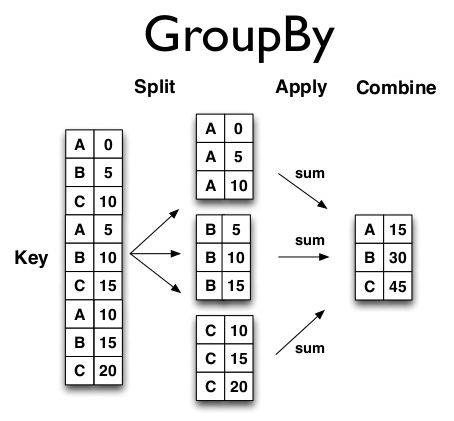

Сначала мы разделяем данные на группы с помощью метода groupby(), после чего к каждой группе применяем агрегацию и объединяем результаты в новую таблицу.

### Группировка данных по одному критерию с одной агрегацией

Рассмотрим группировку данных на примере нашей таблицы с недвижимостью.

Применим агрегирующую функцию среднего к результату работы groupby(). В качестве столбца для группировки возьмём столбец типа объекта недвижимости (Type):

In [57]:
melb_df.groupby(by='Type').mean(numeric_only=True)

,Rooms,Price,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,Lattitude,Longtitude,Propertycount,MeanRoomsSquare,AreaRatio,AgeBuilding
Type,,,,,,,,,,,,,,,
house,3.260874,1.242665e+06,10.979479,3104.080643,3.229336,1.613822,1.772674,617.181924,152.162553,-37.803795,144.994700,7259.025505,18.996731,-0.490031,55.669700
townhouse,2.837522,9.337351e+05,9.851346,3100.777379,2.814183,1.809695,1.555655,279.606822,134.649710,-37.815782,144.996489,7094.459605,18.569847,-0.094916,26.690305
unit,1.963871,6.051275e+05,7.607391,3110.797481,1.966523,1.183295,1.128936,477.314219,102.235863,-37.823710,144.996363,8199.280080,21.068242,0.319883,39.703016


Примечание. Если мы хотим видеть тип объекта в качестве отдельного столбца таблицы, мы можем выставить параметр as_index на False:

In [58]:
melb_df.groupby(by='Type', as_index = False).mean(numeric_only=True)

,Type,Rooms,Price,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,Lattitude,Longtitude,Propertycount,MeanRoomsSquare,AreaRatio,AgeBuilding
0,house,3.260874,1.242665e+06,10.979479,3104.080643,3.229336,1.613822,1.772674,617.181924,152.162553,-37.803795,144.994700,7259.025505,18.996731,-0.490031,55.669700
1,townhouse,2.837522,9.337351e+05,9.851346,3100.777379,2.814183,1.809695,1.555655,279.606822,134.649710,-37.815782,144.996489,7094.459605,18.569847,-0.094916,26.690305
2,unit,1.963871,6.051275e+05,7.607391,3110.797481,1.966523,1.183295,1.128936,477.314219,102.235863,-37.823710,144.996363,8199.280080,21.068242,0.319883,39.703016


Как правило, нам не нужна информация обо всех столбцах, поэтому агрегирующие методы можно применять только к интересующему нас столбцу. Например, давайте сравним средние цены на объекты в зависимости от их типа:

In [59]:
melb_df.groupby('Type')['Price'].mean()

Type
house        1.242665e+06
townhouse    9.337351e+05
unit         6.051275e+05
Name: Price, dtype: float64

Примечание. Обратите внимание, что, так как мы считаем только один показатель (среднее) для одного столбца, в результате мы получаем объект Series.

Из этой маленькой таблицы видно, что наибольшей средней ценой обладают объекты типа house (дома, коттеджи, виллы). Следовательно, можно сделать вывод, что тип постройки является значимым фактором при определении цены объекта недвижимости.

** Теперь давайте выясним, какие регионы (Regionname) наиболее удалены от центра Мельбурна.

Для этого найдём минимальное значение расстояния от центра города до объекта в зависимости от его региона. Результат отсортируем по убыванию расстояния:

In [60]:
melb_df.groupby('Regionname')['Distance'].min().sort_values(ascending=False)

Regionname
Western Victoria              29.8
Eastern Victoria              25.2
Northern Victoria             21.8
South-Eastern Metropolitan    14.7
Eastern Metropolitan           7.8
Western Metropolitan           4.3
Southern Metropolitan          0.7
Northern Metropolitan          0.0
Name: Distance, dtype: float64

### Группировка данных по одному критерию с несколькими агрегациями

Чтобы рассчитать несколько агрегирующих методов, можно воспользоваться ``` методом agg() ```, который принимает список строк с названиями агрегаций.

Давайте построим таблицу для анализа продаж по месяцам. Для этого найдём количество продаж, а также среднее и максимальное значения цен объектов недвижимости (Price), сгруппированных по номеру месяца продажи (MonthSale). Результат отсортируем по количеству продаж в порядке убывания:

In [61]:
melb_df.groupby('MonthSale')['Price'].agg(
    ['count', 'mean', 'max']
).sort_values(by='count', ascending=False)

,count,mean,max
MonthSale,,,
8,1850,1.056371e+06,6500000.0
7,1835,9.314698e+05,9000000.0
5,1644,1.097807e+06,8000000.0
6,1469,1.068981e+06,7650000.0
3,1408,1.146762e+06,5600000.0
4,1246,1.050479e+06,5500000.0
9,1188,1.126349e+06,6400000.0
10,854,1.135970e+06,6250000.0
11,750,1.142503e+06,5050000.0


Примечание. Обратите внимание, что, так как мы считаем несколько показателей для одного столбца, в результате мы получаем объект DataFrame.

В результате применения метода agg(), в который мы передали список с названиями интересующих нас агрегирующих функций, мы получаем DataFrame со столбцами count, mean и max, где для каждого месяца рассчитаны соответствующие параметры. Результат сортируем по столбцу count.

?
Какие интересные выводы можно сделать из этой таблицы?

1
Пик продаж приходится на период весна-лето.

2
Средняя цена продаваемых объектов относительно стабильна и находится в пределах 1 млн. австралийских долларов с небольшими отклонениями (около 100 тыс. влево и вправо).

3
Прослеживается некоторая зависимость между сезоном и максимальной ценой объектов: в месяцы с большим спросом на объекты недвижимости цена также имеет наибольшие показатели. Можно сделать предположение, что это связано с повышением цен на элитные дома в периоды большого спроса.

Примечание. Если вам нужна полная информация обо всех основных статистических характеристиках внутри каждой группы, вы можете воспользоваться методом agg(), передав в качестве его параметра строку 'describe':

In [62]:
melb_df.groupby('MonthSale')['Price'].agg('describe')

,count,mean,std,min,25%,50%,75%,max
MonthSale,,,,,,,,
1,278.0,9.397921e+05,577668.924214,170000.0,570500.0,795000.0,1111250.0,5200000.0
2,333.0,1.169051e+06,671564.357417,131000.0,710000.0,1020000.0,1478000.0,4735000.0
3,1408.0,1.146762e+06,709573.596867,85000.0,680000.0,945000.0,1400000.0,5600000.0
4,1246.0,1.050479e+06,591892.902979,145000.0,655000.0,905500.0,1298750.0,5500000.0
5,1644.0,1.097807e+06,668492.867996,145000.0,650000.0,905000.0,1371250.0,8000000.0
6,1469.0,1.068981e+06,606010.069052,222000.0,660000.0,900000.0,1325000.0,7650000.0
7,1835.0,9.314698e+05,537390.803161,190000.0,586750.0,800000.0,1150000.0,9000000.0
8,1850.0,1.056371e+06,619617.476541,160000.0,635000.0,892000.0,1310000.0,6500000.0
9,1188.0,1.126349e+06,608734.690742,170000.0,725000.0,980000.0,1360000.0,6400000.0


После базовых математических функций наиболее частым агрегированием является подсчёт числа уникальных значений. Так, например, мы можем вычислить число уникальных риелторских компаний в зависимости от региона, чтобы понять, в каких регионах конкуренция на рынке недвижимости меньше. Это можно сделать, передав в параметр метода agg() строку 'nunique'. 

Более того, метод agg() поддерживает использование и других функций. Передадим дополнительно встроенную функцию set, чтобы получить множество из агентств недвижимости, которые работают в каждом из регионов:

In [63]:
melb_df.groupby('Regionname')['SellerG'].agg(['nunique'],set)

,nunique
Regionname,
Eastern Metropolitan,26
Eastern Victoria,11
Northern Metropolitan,40
Northern Victoria,11
South-Eastern Metropolitan,25
Southern Metropolitan,38
Western Metropolitan,34
Western Victoria,6


In [64]:
melb_df.groupby('Regionname')['SellerG'].agg(['nunique'])

,nunique
Regionname,
Eastern Metropolitan,26
Eastern Victoria,11
Northern Metropolitan,40
Northern Victoria,11
South-Eastern Metropolitan,25
Southern Metropolitan,38
Western Metropolitan,34
Western Victoria,6


Задание 3.1

Сгруппируйте данные по признаку количества комнат и найдите среднюю цену объектов недвижимости в каждой группе. В качестве ответа запишите количество комнат, для которых средняя цена наибольшая.

In [65]:
melb_df.groupby('Rooms')['Price'].agg(
    ['count', 'mean', 'max']
).sort_values(by='count', ascending=False)

,count,mean,max
Rooms,,,
3,5881,1.076081e+06,9000000.0
2,3648,7.750812e+05,4800000.0
4,2688,1.445282e+06,7650000.0
1,681,4.338245e+05,2450000.0
5,596,1.870260e+06,8000000.0
6,67,1.849366e+06,6500000.0
7,10,1.920700e+06,4050000.0
8,8,1.602750e+06,2950000.0
10,1,9.000000e+05,900000.0


Задание 3.2

Какой регион имеет наименьшее стандартное отклонение по географической широте (Lattitude)?
В качестве ответа запишите название этого региона.

In [66]:
melb_df.groupby('Regionname')['Lattitude'].agg(
    ['count', 'std']
).sort_values(by='count', ascending=False)

,count,std
Regionname,,
Southern Metropolitan,4695,0.043080
Northern Metropolitan,3890,0.049639
Western Metropolitan,2948,0.051251
Eastern Metropolitan,1471,0.047890
South-Eastern Metropolitan,450,0.073411
Eastern Victoria,53,0.147067
Northern Victoria,41,0.084455
Western Victoria,32,0.011579


Задание 3.3

Какая риелторская компания (SellerG) имеет наименьшую общую выручку за период с 1 мая по 1 сентября (включительно) 2017 года?
Для ответа на этот вопрос рассчитайте сумму продаж (Price) каждой компании в заданный период.
Не забудьте перевести даты в формат datetime

In [67]:
date1 = pd.to_datetime('2017-05-01')
date2 = pd.to_datetime('2017-09-01')
mask = (date1 <= melb_df['Date']) & (melb_df['Date']<= date2)
melb_df[mask].groupby('SellerG')['Price'].sum().sort_values(ascending=True)

SellerG
LITTLE             2742000.0
Cayzer             4439000.0
Burnham            4550500.0
Moonee             7328000.0
Thomson            8332000.0
Bells              8656000.0
Alexkarbon        10985000.0
McDonald          14637500.0
Rendina           15422276.0
Nick              16890000.0
Douglas           18341000.0
Buckingham        19033000.0
C21               19515000.0
Eview             19791500.0
Collins           20217000.0
Philip            22051800.0
Chisholm          23225000.0
Williams          23297000.0
Love              23365500.0
Purplebricks      23401000.0
O'Brien           23855508.0
HAR               25568000.0
Village           26473000.0
RW                29261000.0
Raine             30687700.0
Stockdale         35409800.0
Sweeney           36882750.0
Gary              39138400.0
Hodges            43231000.0
YPA               46354350.0
Miles             47582000.0
Kay               48569500.0
RT                50498000.0
Brad              55955000.0
Jas   

## Сводные таблицы

#### **Метод groupby как способ построения сводных таблиц**

На самом деле мы с вами уже строили простейшие одномерные сводные таблицы с помощью метода groupby — мы рассматривали сводную таблицу в контексте группировки по одному признаку. 

Например, мы уже умеем строить таблицу, которая показывает зависимость медианной цены и площади здания от числа комнат:

In [68]:
melb_df.groupby('Rooms')[['Price', 'BuildingArea']].median()

,Price,BuildingArea
Rooms,,
1,385000.0,107.0
2,690000.0,126.0
3,950000.0,126.0
4,1285000.0,142.0
5,1660000.0,176.0
6,1800000.0,126.0
7,1496000.0,216.5
8,1515000.0,126.0
10,900000.0,126.0


Также можно построить таблицу, в которой мы будем учитывать не только число комнат, но и тип здания (Type). Для этого в параметрах метода groupby() укажем список из нескольких интересующих нас столбцов.

In [69]:
melb_df.groupby(['Rooms', 'Type'])['Price'].mean()

Rooms  Type     
1      house        8.668655e+05
       townhouse    5.927045e+05
       unit         3.899289e+05
2      house        1.017238e+06
       townhouse    7.101585e+05
       unit         6.104905e+05
3      house        1.109233e+06
       townhouse    9.847087e+05
       unit         8.505963e+05
4      house        1.462283e+06
       townhouse    1.217092e+06
       unit         1.037476e+06
5      house        1.877327e+06
       townhouse    1.035000e+06
6      house        1.869508e+06
       unit         5.200000e+05
7      house        1.920700e+06
8      house        1.510286e+06
       unit         2.250000e+06
10     house        9.000000e+05
Name: Price, dtype: float64

В результате выполнения такого кода мы получаем Series, которая обладает несколькими уровнями индексов: первый уровень — число комнат, второй уровень — тип здания. Такая организация индексов называется ***иерархической***. Вычисление параметра (средней цены) происходит во всех возможных комбинациях признаков.

Для того, чтобы финальный результат был представлен в виде сводной таблицы (первый группировочный признак по строкам, а второй — по столбцам), а не в виде Series с иерархическими индексами, к результату чаще всего применяют метод **unstack()**, который позволяет переопределить вложенный индекс в виде столбцов таблицы:

In [70]:
melb_df.groupby(['Rooms', 'Type'])['Price'].mean().unstack()

Type,house,townhouse,unit
Rooms,,,
1,8.668655e+05,5.927045e+05,3.899289e+05
2,1.017238e+06,7.101585e+05,6.104905e+05
3,1.109233e+06,9.847087e+05,8.505963e+05
4,1.462283e+06,1.217092e+06,1.037476e+06
5,1.877327e+06,1.035000e+06,NaN
6,1.869508e+06,NaN,5.200000e+05
7,1.920700e+06,NaN,NaN
8,1.510286e+06,NaN,2.250000e+06
10,9.000000e+05,NaN,NaN


В результате мы получаем сводную таблицу, столбцы в которой представляют типы домов (house, townhouse, unit), строки — число комнат, а на пересечении строк и столбцов находится средняя стоимость объекта с такими показателями.

Какие интересные выводы можно сделать из этой таблицы?

* 1
Пропуски в сводной таблице (NaN) говорят о том, что в наших данных нет соответствующих комбинаций признаков. Например, у нас нет информации о ценах на таунхаусы, где количество комнат больше пяти.

* 2
Наибольшей средней стоимостью (2,25 млн. австралийских долларов) обладают объекты типа unit с восемью жилыми комнатами. Наименьшая средняя стоимость — у однокомнатных домов типа unit (чуть меньше 400 тыс. австралийских долларов).

* 3
Сколько бы комнат ни было в доме, цена на объекты типа unit всегда ниже других (за исключением восьмикомнатных объектов).

## Метод pivot_table для построения сводных таблиц

На самом деле метод groupby редко используется при двух параметрах, так как для построения сводных таблиц существует специальный и более простой метод — ***pivot_table()***.

Основные параметры метода ```pivot_table():```

* ```values``` — имя столбца, по которому необходимо получить сводные данные, применяя агрегирующую функцию;
* ```index``` — имя столбца, значения которого станут строками сводной таблицы;
* ```columns``` — имя столбца, значения которого станут столбцами сводной таблицы;
* ```aggfunc``` — имя или список имён агрегирующих функций (по умолчанию — подсчёт среднего, 'mean');
* ```fill_value``` — значение, которым необходимо заполнить пропуски (по умолчанию пропуски не заполняются).

Давайте построим ту же самую таблицу, но уже с использованием метода pivot_table. В качестве параметра values укажем столбец Price, в качестве индексов сводной таблицы возьмём Rooms, а в качестве столбцов — Type. Агрегирующую функцию оставим по умолчанию (среднее). Дополнительно заменим пропуски в таблице на значение 0. Финальный результат для наглядности вывода округлим с помощью метода round() до целых.

In [71]:
melb_df.pivot_table(
    values='Price',
    index='Rooms',
    columns='Type',
    fill_value=0
).round()

Type,house,townhouse,unit
Rooms,,,
1,866866.0,592705.0,389929.0
2,1017238.0,710158.0,610491.0
3,1109233.0,984709.0,850596.0
4,1462283.0,1217092.0,1037476.0
5,1877327.0,1035000.0,0.0
6,1869508.0,0.0,520000.0
7,1920700.0,0.0,0.0
8,1510286.0,0.0,2250000.0
10,900000.0,0.0,0.0


*А теперь давайте проанализируем продажи в каждом из регионов в зависимости от того, будний был день или выходной. Для этого построим сводную таблицу, в которой строками будут являться названия регионов (Regionname), а в столбцах будет располагаться наш «признак-мигалка» выходного дня (Weekend), который равен 1, если день был выходным, и 0 — в противном случае. В качестве значений сводной таблицы возьмём количество продаж.*

In [72]:
melb_df.pivot_table(
    values='Price',
    index='Regionname',
    columns='Weekend',
    aggfunc='count'
)

Weekend,0,1
Regionname,,
Eastern Metropolitan,447,1024
Eastern Victoria,13,40
Northern Metropolitan,1258,2632
Northern Victoria,11,30
South-Eastern Metropolitan,123,327
Southern Metropolitan,1534,3161
Western Metropolitan,960,1988
Western Victoria,8,24


Из результирующей таблицы можно сделать два вывода:

* 1
Число продаж резко возрастает в выходные вне зависимости от региона (приблизительно в 2-3 раза). То есть вероятность того, что дом продадут в выходные, гораздо выше вероятности, что его продадут в будний день.

* 2
В отдалённых регионах (Victoria) коэффициент роста числа продаж выше, чем в центральных. Если в центральных регионах Metropolitan продажи по выходным в 2-2.5 раза выше, чем по будням, то в регионах Victoria число продаж в выходные вырастает примерно в 3 раза.

Такой рост можно даже попытаться объяснить логически: в выходные дни у людей появляется свободное время, чтобы доехать до отдалённых пригородов с целью покупки дома.

--------

*Разберём ещё один пример: найдём, как зависит средняя и медианная площадь участка (Landsize) от типа объекта (Type) и его региона (Regionname). Чтобы посмотреть несколько статистических параметров, нужно передать в аргумент aggfunc список из агрегирующих функций. Построим такую сводную таблицу, где пропущенные значения заменим на 0:*

In [73]:
melb_df.pivot_table(
    values='Landsize',
    index='Regionname',
    columns='Type',
    aggfunc=['median', 'mean'],
    fill_value=0
)

median                          mean              \
Type                        house townhouse   unit        house   townhouse   
Regionname                                                                    
Eastern Metropolitan        674.0     233.5  203.0   717.422847  269.440678   
Eastern Victoria            843.0       0.0  230.0  3108.960000    0.000000   
Northern Metropolitan       459.5     134.0    0.0   619.249092  317.325733   
Northern Victoria           724.0       0.0    0.0  3355.463415    0.000000   
South-Eastern Metropolitan  630.5     240.0  199.0   664.306701  212.160000   
Southern Metropolitan       586.0     246.0    0.0   569.643881  278.858824   
Western Metropolitan        531.0     198.0   62.0   507.883406  244.560669   
Western Victoria            599.5       0.0    0.0   655.500000    0.000000   

                                        
Type                              unit  
Regionname                              
Eastern Metropolitan        330.444444  
Eastern Victoria            295.333333  
Northern Metropolitan       495.026538  
Northern Victoria             0.000000  
South-Eastern Metropolitan  357.864865  
Southern Metropolitan       466.380245  
Western Metropolitan        557.637232  
Western Victoria              0.000000

## Многомерные сводные таблицы

До этого мы рассматривали, как некоторый статистический показатель может зависеть от двух признаков. Однако, как уже упоминалось, сводные таблицы позволяют наблюдать зависимость и от большего числа признаков. Такие сводные таблицы называются **многомерными**. 

``` Для того чтобы исследовать зависимость от большего числа признаков, можно передать список признаков в параметр index или параметр columns. ```

*Давайте построим таблицу, в которой по индексам будут располагаться признаки метода продажи (Method) и типа объекта (Type), по столбцам — наименование региона (Regionname), а на пересечении строк и столбцов будет стоять медианная цена объекта (Price):*

In [74]:
melb_df.pivot_table(
    values='Price',
    index=['Method','Type'],
    columns='Regionname',
    aggfunc='median',
    fill_value=0
)

Regionname        Eastern Metropolitan  Eastern Victoria  \
Method Type                                                
PI     house                 1244000.0          780000.0   
       townhouse              760000.0               0.0   
       unit                   650000.0               0.0   
S      house                 1127000.0          675000.0   
       townhouse              828000.0               0.0   
       unit                   645750.0          492000.0   
SA     house                  932500.0          950000.0   
       townhouse              807500.0               0.0   
       unit                        0.0               0.0   
SP     house                 1050000.0          672500.0   
       townhouse              910000.0               0.0   
       unit                   515000.0          400000.0   
VB     house                 1100000.0          712500.0   
       townhouse              892500.0               0.0   
       unit                   500000.0               0.0   

Regionname        Northern Metropolitan  Northern Victoria  \
Method Type                                                  
PI     house                   900000.0           500000.0   
       townhouse               632500.0                0.0   
       unit                    410000.0                0.0   
S      house                   920000.0           555000.0   
       townhouse               750000.0                0.0   
       unit                    525500.0                0.0   
SA     house                   817500.0           540000.0   
       townhouse               425000.0                0.0   
       unit                    616000.0                0.0   
SP     house                   900000.0           521000.0   
       townhouse               690000.0                0.0   
       unit                    470000.0                0.0   
VB     house                  1050000.0           690000.0   
       townhouse               640000.0                0.0   
       unit                    450000.0                0.0   

Regionname        South-Eastern Metropolitan  Southern Metropolitan  \
Method Type                                                           
PI     house                        865000.0              1725000.0   
       townhouse                   1190000.0              1055000.0   
       unit                         525000.0               571250.0   
S      house                        883300.0              1611000.0   
       townhouse                    875000.0              1135000.0   
       unit                         606000.0               655000.0   
SA     house                        880000.0              1390000.0   
       townhouse                         0.0              1141000.0   
       unit                              0.0               580000.0   
SP     house                        770000.0              1521750.0   
       townhouse                    800000.0              1162500.0   
       unit                         601000.0               550000.0   
VB     house                        850000.0              1800000.0   
       townhouse                         0.0              1250000.0   
       unit                         700000.0               500000.0   

Regionname        Western Metropolitan  Western Victoria  
Method Type                                               
PI     house                  870000.0          630000.0  
       townhouse              670000.0               0.0  
       unit                   360000.0               0.0  
S      house                  870000.0          397500.0  
       townhouse              729000.0               0.0  
       unit                   489000.0               0.0  
SA     house                  772500.0               0.0  
       townhouse              467500.0               0.0  
       unit                   571000.0               0.0  
SP     house                  865000.0          360000.0  
       t

## Доступ к данным в сводной таблице

Давайте рассмотрим, что собой представляют столбцы сложной сводной таблицы.

Запишем сводную таблицу, которую мы создавали ранее в переменную pivot:

In [75]:
pivot = melb_df.pivot_table(
    values='Landsize',
    index='Regionname',
    columns='Type',
    aggfunc=['median', 'mean'],
    fill_value=0
)

Выведем её столбцы с помощью атрибута ***columns:***

In [76]:
pivot.columns

MultiIndex([('median',     'house'),
            ('median', 'townhouse'),
            ('median',      'unit'),
            (  'mean',     'house'),
            (  'mean', 'townhouse'),
            (  'mean',      'unit')],
           names=[None, 'Type'])

*В результате мы получаем объект MultiIndex. Этот объект хранит в себе шесть комбинаций пар столбцов (два статистических параметра и три типа здания), то есть есть шесть возможных вариантов обращения к столбцам таблицы.*

*Мультииндексы раскрываются подобно вложенным словарям — по очереди, как матрёшка. Чтобы получить доступ к определённому столбцу, вы должны сначала обратиться к столбцу, который находится уровнем выше.*

Так, из таблицы pivot мы можем получить средние значения площадей участков для типа здания unit, просто последовательно обратившись по имени столбцов:

In [77]:
display(pivot['mean']['unit'])

Regionname
Eastern Metropolitan          330.444444
Eastern Victoria              295.333333
Northern Metropolitan         495.026538
Northern Victoria               0.000000
South-Eastern Metropolitan    357.864865
Southern Metropolitan         466.380245
Western Metropolitan          557.637232
Western Victoria                0.000000
Name: unit, dtype: float64

*Аналогично производится и фильтрация данных. Например, если нам нужны регионы, в которых средняя площадь здания для домов типа house меньше их медианной площади, то мы можем найти их следующим образом:*

In [78]:
mask = pivot['mean']['house'] < pivot['median']['house']
filtered_pivot = pivot[mask]
display(filtered_pivot)

median                        mean              \
Type                   house townhouse  unit       house   townhouse   
Regionname                                                             
Southern Metropolitan  586.0     246.0   0.0  569.643881  278.858824   
Western Metropolitan   531.0     198.0  62.0  507.883406  244.560669   

                                   
Type                         unit  
Regionname                         
Southern Metropolitan  466.380245  
Western Metropolitan   557.637232

Чтобы получить индексы отфильтрованной таблицы, можно воспользоваться атрибутом index и обернуть результат в список:

In [79]:
print(list(filtered_pivot.index))

['Southern Metropolitan', 'Western Metropolitan']


Примечание. На самом деле мультииндексные таблицы можно создавать и вручную. Давайте посмотрим на синтаксис данной конструкции:

In [80]:
import numpy as np
mser = pd.Series(
    np.random.rand(8),
	index=[['white','white','white','blue','blue','red','red','red'], 
           ['up','down','right','up','down','up','down','left']])
display(mser)

white  up       0.374072
       down     0.176555
       right    0.198995
blue   up       0.294912
       down     0.388150
red    up       0.812219
       down     0.303445
       left     0.819545
dtype: float64

В данном примере мы создаём объект Series со вложенными индексами. Мы передаём в качестве индексов Series вложенный список, где первый список задаёт внешний уровень вложенности, а второй список — внутренний уровень вложенности. Значения Series — случайные числа от 0 до 1, сгенерированные функцией ```np.random.rand()``` (ваши значения могут отличаться).

Если посмотреть на индексы Series, можно увидеть, что они являются мультииндексами:

In [81]:
print(mser.index)

MultiIndex([('white',    'up'),
            ('white',  'down'),
            ('white', 'right'),
            ( 'blue',    'up'),
            ( 'blue',  'down'),
            (  'red',    'up'),
            (  'red',  'down'),
            (  'red',  'left')],
           )


Аналогично создаются DataFrame со вложенными признаками (вложенными столбцами) — для этого вложенный список передаётся в параметр columns при инициализации таблицы:

In [85]:
mframe = pd.DataFrame(
    np.random.randn(16).reshape(4,4),
    index=[['white','white','red','red'], ['up','down','up','down']],
    columns=[['pen','pen','paper','paper'],[1,2,1,2]]
)
display(mframe)

pen               paper          
                   1         2         1         2
white up   -0.000835  0.597780  0.371836 -1.236664
      down  1.412619 -1.144867 -0.343947 -0.236405
red   up    0.784079 -0.591208  1.050603 -0.526468
      down  0.501030 -0.565429 -0.313800  1.336498

***Задание 4.2***

Составьте сводную таблицу, которая показывает зависимость медианной площади (BuildingArea) здания от типа объекта недвижимости (Type) и количества жилых комнат в доме (Rooms). Для какой комбинации признаков площадь здания наибольшая?
В качестве ответа запишите эту комбинацию (тип здания, число комнат) через запятую, без пробелов.

In [95]:
melb_df.groupby(['Type', 'Rooms'])['BuildingArea'].median()

Type       Rooms
house      1        126.0
           2        126.0
           3        126.0
           4        141.0
           5        177.0
           6        126.0
           7        216.5
           8        126.0
           10       126.0
townhouse  1         88.0
           2        114.0
           3        126.0
           4        159.5
           5        152.0
unit       1         69.5
           2        110.0
           3        126.0
           4        126.0
           6        171.0
           8        126.0
Name: BuildingArea, dtype: float64

***Задание 4.3***

Составьте сводную таблицу, которая показывает зависимость медианной цены объекта недвижимости (Price) от риелторского агентства (SellerG) и типа здания (Type).
Во вновь созданной таблице найдите агентство, у которого медианная цена для зданий типа unit максимальна. В качестве ответа запишите название этого агентства.

In [96]:
melb_df.pivot_table(
    values='Price',
    index='SellerG',
    columns='Type',
    aggfunc=['median', 'max'],
    fill_value=0
)

median                             max                      
Type               house  townhouse      unit      house  townhouse       unit
SellerG                                                                       
Alexkarbon     1036250.0   935000.0  560000.0  2370000.0  1171000.0   995000.0
Barry           830000.0   727500.0  502000.0  2620000.0  1350000.0  1500000.0
Bells           692500.0   430500.0  457500.0  1350500.0   521000.0   660000.0
Biggin         1151750.0   675000.0  548000.0  4250000.0  1630000.0  1296000.0
Brad            875000.0   700000.0  465000.0  2650000.0  1130000.0  1170000.0
Buckingham      830000.0   820000.0  553000.0  1301000.0  1405000.0   566000.0
Burnham         922500.0        0.0  305000.0  1200000.0        0.0   520000.0
Buxton         1323750.0  1030000.0  670000.0  4050000.0  2100000.0  1620000.0
C21             836500.0   768750.0  625500.0  2385000.0   817500.0  1096000.0
Cayzer         1505000.0  1450000.0  707500.0  2800000.0  1565000.0  1631000.0
Chisholm       1520000.0   950000.0  640000.0  2860000.0  1600000.0  1340000.0
Collins        1566500.0   930000.0  592000.0  3970000.0  1015000.0   885500.0
Douglas         684000.0   500000.0  494500.0  1060000.0   580000.0   600000.0
Eview           760000.0   597500.0  602000.0  1905000.0   790000.0   639000.0
Fletchers      1390000.0  1238000.0  653000.0  3270000.0  2050000.0  1330000.0
Gary           1370000.0   993500.0  550000.0  2830000.0  2570000.0  1190000.0
Greg           1330000.0   900000.0  547500.0  4100000.0  1750000.0  2250000.0
HAR             695000.0        0.0  518000.0  2375000.0        0.0  1900000.0
Harcourts       740000.0   653750.0  500000.0  2350000.0  1315000.0   732000.0
Hodges         1500000.0  1105000.0  605500.0  4700000.0  2300000.0  1400000.0
Jas             935000.0   699000.0  455000.0  3400000.0  1070000.0   886000.0
Jellis         1505000.0  1052000.0  591750.0  6500000.0  2650000.0  3625000.0
Kay            2220000.0  1365000.0  695000.0  6250000.0  2900000.0  2050000.0
LITTLE          970000.0   800000.0  447000.0  1535000.0   800000.0   857000.0
Love            780000.0   846000.0  440000.0  1680000.0   910000.0   716000.0
Marshall       1975000.0  1408500.0  715000.0  6400000.0  3475000.0  2460000.0
McDonald       1242500.0        0.0  502500.0  2355000.0        0.0   825000.0
McGrath        1250000.0   810000.0  542500.0  4300000.0  2221000.0  1135000.0
Miles          1090000.0   721500.0  555000.0  3850000.0  1010000.0  1260000.0
Moonee          806000.0   715000.0  622000.0  1250000.0   880000.0   765000.0
Nelson         1055000.0   730000.0  530000.0  4011000.0  1410000.0  1935000.0
Nick           2025000.0   780000.0  900000.0  3900000.0   780000.0  1410000.0
Noel           1400500.0   990000.0  693250.0  2855000.0  1963000.0   980000.0
O'Brien         737504.0   430000.0  618500.0  1850000.0   495000.0   724000.0
Philip         1035000.0   701000.0  636000.0  1765000.0   840000.0  1070000.0
Purplebricks    810000.0   927500.0  582500.0  2190000.0  1200000.0   670000.0
RT             1640000.0  1400000.0  630000.0  5510000.0  1586000.0  2050000.0
RW              870000.0   630500.0  625500.0  3690000.0   678000.0   750000.0
Raine           745000.0   608000.0  447500.0  2255000.0  1370000.0   650000.0
Ray             900000.0   650000.0  497500.0  2718000.0  1201000.0  1220500.0
Rendina        1190000.0   750000.0  459000.0  2905000.0   895000.0   730000.0
Stockdale       715500.0   550000.0  410000.0  2450000.0   750000.0   725000.0
Sweeney         850000.0   728000.0  381000.0  2760000.0  1040000.0   801250.0
Thomson        1177000.0   500000.0  495000.0  1675000.0   900000.0   983500.0
Village         973500.0   727500.0  420000.0  2450000.0   962000.0   510000.0
Williams       1161000.0   735000.0  577000.0  2640000.0  1715000.0  1450000.0
Woodards       1261000.0   865500.0  600000.0  3750000.0  1350000.0  1770000.0
YPA             596250.0   498500.0  443500.0  1335000.0   607000.0 